In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('BASE_2_Clientes_Manga.xlsx')

In [2]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

target = "importancia_preco"

features = [
    "volume_tipico_compra_ton_mes",
    "importancia_certificacoes",
    "aceita_refugo_como_mp",
    "tipo_cliente",
    "frequencia_compra_mensal",
    "importancia_manga_produto_final_1a10"
]

cat_features = [
    "importancia_certificacoes",
    "aceita_refugo_como_mp",
    "tipo_cliente"
]

df_train = df[df[target].notna()].copy()
df_missing = df[df[target].isna()].copy()

X = df_train[features]
y = df_train[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train, cat_features=cat_features)

y_pred = model.predict(X_test)

# CatBoost às vezes retorna shape (n, 1)
if isinstance(y_pred, (np.ndarray,)) and y_pred.ndim > 1:
    y_pred = y_pred.ravel()

# se vier como lista de listas, também resolve
y_pred = np.array(y_pred).ravel()

# =========================
# MÉTRICAS (ordem prática)
# =========================
f1_macro = f1_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print("✅ Métricas (macro):")
print(f"1) F1 macro           : {f1_macro:.4f}")
print(f"2) Recall macro       : {recall_macro:.4f}")
print(f"3) Precision macro    : {precision_macro:.4f}")
print(f"4) Balanced accuracy  : {bal_acc:.4f}")

# =========================
# MATRIZ DE CONFUSÃO
# =========================
labels = sorted(pd.Series(y_test).dropna().unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"real_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])

print("\n✅ Matriz de confusão:")
display(cm_df)

# =========================
# (extra útil) relatório por classe
# =========================
print("\n✅ Relatório por classe:")
print(classification_report(y_test, y_pred, zero_division=0))

from sklearn.metrics import f1_score

pred_train = model.predict(X_train).ravel()
pred_test  = model.predict(X_test).ravel()

print("F1 macro treino:", f1_score(y_train, pred_train, average="macro"))
print("F1 macro teste :", f1_score(y_test,  pred_test,  average="macro"))

target = "importancia_preco"

df_missing = df[df[target].isna()].copy()
df_observed = df[df[target].notna()].copy()
pred_missing = model.predict(df_missing[features])

# garante formato correto
import numpy as np
pred_missing = np.array(pred_missing).ravel()

df.loc[df[target].isna(), target] = pred_missing

✅ Métricas (macro):
1) F1 macro           : 0.6562
2) Recall macro       : 0.6586
3) Precision macro    : 0.6555
4) Balanced accuracy  : 0.6586

✅ Matriz de confusão:


,pred_Alta,pred_Baixa,pred_Média
real_Alta,517,0,111
real_Baixa,4,168,67
real_Média,147,77,183



✅ Relatório por classe:
              precision    recall  f1-score   support

        Alta       0.77      0.82      0.80       628
       Baixa       0.69      0.70      0.69       239
       Média       0.51      0.45      0.48       407

    accuracy                           0.68      1274
   macro avg       0.66      0.66      0.66      1274
weighted avg       0.67      0.68      0.68      1274

F1 macro treino: 0.6751106413147324
F1 macro teste : 0.6562056274019658


In [6]:
features = [
    'tipo_cliente',
    'importancia_manga_produto_final_1a10',
    'importancia_preco',
    'importancia_certificacoes',
    'aceita_refugo_como_mp',
    'volume_tipico_compra_ton_mes',
    'frequencia_compra_mensal'
]

df_cluster = df[features].copy()

df_cluster = df_cluster.astype(str)
cat_cols = [
    'tipo_cliente',
    'importancia_preco',
    'importancia_certificacoes',
    'aceita_refugo_como_mp'
]

cat_cols_idx = [df_cluster.columns.get_loc(col) for col in cat_cols]


In [7]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'importancia_manga_produto_final_1a10',
    'volume_tipico_compra_ton_mes',
    'frequencia_compra_mensal'
]

scaler = StandardScaler()

df_cluster[num_cols] = scaler.fit_transform(
    df_cluster[num_cols].astype(float)
)

In [9]:
from kmodes.kprototypes import KPrototypes

kproto = KPrototypes(
    n_clusters=3,
    init='Cao',
    n_init=10,
    verbose=2,
    random_state=42
)

clusters = kproto.fit_predict(
    df_cluster.values,
    categorical=cat_cols_idx
)

df['cluster'] = clusters


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 1700, ncost: 16050.036192859972
Run: 1, iteration: 2/100, moves: 845, ncost: 15660.054446174201
Run: 1, iteration: 3/100, moves: 222, ncost: 15641.160662193155
Run: 1, iteration: 4/100, moves: 81, ncost: 15636.538627752712
Run: 1, iteration: 5/100, moves: 48, ncost: 15634.04312478809
Run: 1, iteration: 6/100, moves: 32, ncost: 15633.096670515386
Run: 1, iteration: 7/100, moves: 15, ncost: 15632.657300833105
Run: 1, iteration: 8/100, moves: 8, ncost: 15632.43018134228
Run: 1, iteration: 9/100, moves: 8, ncost: 15632.260980124043
Run: 1, iteration: 10/100, moves: 11, ncost: 15632.11028516202
Run: 1, iteration: 11/100, moves: 7, ncost: 15632.06207913029
Run: 1, iteration: 12/100, moves: 7, ncost: 15631.87204803183
Run: 1, iteration: 13/100, moves: 9, ncost: 15631.59822270679
Run: 1, iteration: 14/100, m

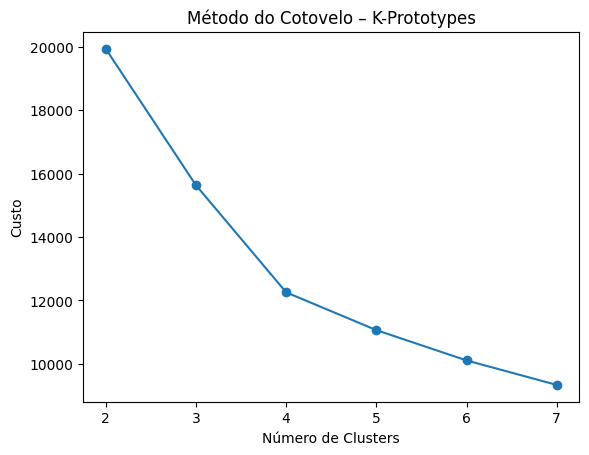

In [15]:
cost = []

for k in range(2, 8):
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=5,
        verbose=0,
        random_state=42
    )
    
    kproto.fit_predict(
        df_cluster.values,
        categorical=cat_cols_idx
    )
    
    cost.append(kproto.cost_)

import matplotlib.pyplot as plt

plt.plot(range(2, 8), cost, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Custo')
plt.title('Método do Cotovelo – K-Prototypes')
plt.show()


In [19]:
# ============================================
# K-PROTOTYPES (k=4) - CÓDIGO COMPLETO (1 CÉLULA)
# ============================================

import numpy as np
import pandas as pd

# (se precisar instalar, descomente a linha abaixo)
# !pip install kmodes

from kmodes.kprototypes import KPrototypes

# ----------------------------
# 1) DEFINIÇÃO DAS FEATURES
# ----------------------------
features_kproto = [
    'importancia_manga_produto_final_1a10',  # numérica
    'volume_tipico_compra_ton_mes',          # numérica
    'frequencia_compra_mensal',              # numérica
    'importancia_preco',                     # categórica
    'importancia_certificacoes',             # categórica
    'aceita_refugo_como_mp'                  # categórica
]

# ----------------------------
# 2) PREPARO DO DATAFRAME
#    (Aqui é importante NÃO mapear categorias para números no K-Prototypes)
# ----------------------------
df_kproto = df.copy()

# garante que categóricas são strings (evita problemas com NaN, números, etc.)
cat_cols = ['importancia_preco', 'importancia_certificacoes', 'aceita_refugo_como_mp']
for c in cat_cols:
    df_kproto[c] = df_kproto[c].astype('string').fillna('NA').str.strip()

# trata numéricas (se tiver NaN, você pode ajustar a estratégia)
num_cols = ['importancia_manga_produto_final_1a10', 'volume_tipico_compra_ton_mes', 'frequencia_compra_mensal']
for c in num_cols:
    df_kproto[c] = pd.to_numeric(df_kproto[c], errors='coerce')

# se houver nulos em numéricas, imputação simples pela mediana (pode trocar por média, etc.)
for c in num_cols:
    df_kproto[c] = df_kproto[c].fillna(df_kproto[c].median())

X_kproto = df_kproto[features_kproto]

# ----------------------------
# 3) RODA O K-PROTOTYPES (k=4)
# ----------------------------
categorical_indexes = [3, 4, 5]  # posições das colunas categóricas no array

kproto = KPrototypes(
    n_clusters=4,
    init='Cao',
    n_init=10,
    random_state=42
)

clusters_kproto = kproto.fit_predict(
    X_kproto.to_numpy(),
    categorical=categorical_indexes
)

df_kproto['cluster_kproto'] = clusters_kproto

# ----------------------------
# 4) PERFIL DOS CLUSTERS
#    - numéricas: média
#    - categóricas: moda
# ----------------------------
perfil_numerico = df_kproto.groupby('cluster_kproto')[num_cols].mean().round(2)

perfil_categorico = df_kproto.groupby('cluster_kproto')[cat_cols].agg(
    lambda s: s.mode().iloc[0] if not s.mode().empty else 'NA'
)

perfil_completo = pd.concat([perfil_numerico, perfil_categorico], axis=1)

print("\n==============================")
print("PERFIL COMPLETO (K-PROTOTYPES)")
print("==============================")
display(perfil_completo)

# ----------------------------
# 5) TAMANHO DOS CLUSTERS
# ----------------------------
print("\n==============================")
print("TAMANHO DOS CLUSTERS")
print("==============================")
display(df_kproto['cluster_kproto'].value_counts().sort_index())

# ----------------------------
# 6) DISTRIBUIÇÃO POR TIPO_CLIENTE (se existir)
# ----------------------------
if 'tipo_cliente' in df_kproto.columns:
    print("\n=========================================")
    print("CLUSTER x TIPO_CLIENTE (NORMALIZE=INDEX)")
    print("=========================================")
    display(
        pd.crosstab(
            df_kproto['cluster_kproto'],
            df_kproto['tipo_cliente'],
            normalize='index'
        ).round(2)
    )

# ----------------------------
# 7) CENTRÓIDES (ROBUSTO PARA DIFERENTES VERSÕES DO kmodes)
# ----------------------------
print("\n==============================")
print("CENTRÓIDES (FORMATO COMPLETO)")
print("==============================")

cent = kproto.cluster_centroids_

# Caso A) algumas versões retornam [centroides_num, centroides_cat]
if isinstance(cent, (list, tuple)) and len(cent) == 2:
    cent_num_arr, cent_cat_arr = cent[0], cent[1]

    cent_num = pd.DataFrame(cent_num_arr, columns=num_cols).round(2)
    cent_cat = pd.DataFrame(cent_cat_arr, columns=cat_cols)

    print("\n--- NUMÉRICOS ---")
    display(cent_num)

    print("\n--- CATEGÓRICOS ---")
    display(cent_cat)

# Caso B) outras versões retornam um único array com tudo junto (num + cat)
else:
    cent_all = pd.DataFrame(cent, columns=features_kproto)

    # tenta arredondar só as colunas numéricas (se der erro, ignora)
    for c in num_cols:
        cent_all[c] = pd.to_numeric(cent_all[c], errors='coerce')

    cent_all[num_cols] = cent_all[num_cols].round(2)

    display(cent_all)

    print("\n--- NUMÉRICOS (extraído) ---")
    display(cent_all[num_cols])

    print("\n--- CATEGÓRICOS (extraído) ---")
    display(cent_all[cat_cols])


# ----------------------------
# 8) (OPCIONAL) SALVAR DF COM CLUSTERS
# ----------------------------
# df_kproto.to_excel("df_com_cluster_kproto.xlsx", index=False)



PERFIL COMPLETO (K-PROTOTYPES)


,importancia_manga_produto_final_1a10,volume_tipico_compra_ton_mes,frequencia_compra_mensal,importancia_preco,importancia_certificacoes,aceita_refugo_como_mp
cluster_kproto,,,,,,
0,7.41,356.42,3.59,Média,Baixa,Não
1,6.01,2269.49,2.50,Alta,Alta,Sim
2,8.10,1091.98,3.31,Alta,Média,Sim
3,7.80,1591.10,3.21,Alta,Média,Sim



TAMANHO DOS CLUSTERS


cluster_kproto
0    3186
1     570
2    1618
3    1626
Name: count, dtype: int64


CLUSTER x TIPO_CLIENTE (NORMALIZE=INDEX)


...

,importancia_manga_produto_final_1a10,volume_tipico_compra_ton_mes,frequencia_compra_mensal,importancia_preco,importancia_certificacoes,aceita_refugo_como_mp
0,7.41,356.42,3.59,Média,Baixa,Não
1,6.01,2269.49,2.50,Alta,Alta,Sim
2,8.10,1091.98,3.31,Alta,Média,Sim
3,7.80,1591.10,3.21,Alta,Média,Sim



--- NUMÉRICOS (extraído) ---


,importancia_manga_produto_final_1a10,volume_tipico_compra_ton_mes,frequencia_compra_mensal
0,7.41,356.42,3.59
1,6.01,2269.49,2.50
2,8.10,1091.98,3.31
3,7.80,1591.10,3.21



--- CATEGÓRICOS (extraído) ---


,importancia_preco,importancia_certificacoes,aceita_refugo_como_mp
0,Média,Baixa,Não
1,Alta,Alta,Sim
2,Alta,Média,Sim
3,Alta,Média,Sim
